# Hypothesis testing

In [76]:
library(tidyverse)
library(readxl)
install.packages("extrafont") # Install extrafont
library(extrafont) # Load extrafont for consistent font handling
font_import(prompt = FALSE) # Import system fonts (can take a few minutes)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘extrafontdb’, ‘Rttf2pt1’


Registering fonts with R

Scanning ttf files in /usr/share/fonts/, /usr/local/share/fonts/ ...

Extracting .afm files from .ttf files...

/usr/share/fonts/truetype/humor-sans/Humor-Sans.ttf
 => /usr/local/lib/R/site-library/extrafontdb/metrics/Humor-Sans

/usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf
 => /usr/local/lib/R/site-library/extrafontdb/metrics/LiberationMono-Bold

/usr/share/fonts/truetype/liberation/LiberationMono-BoldItalic.ttf
 => /usr/local/lib/R/site-library/extrafontdb/metrics/LiberationMono-BoldItalic

/usr/share/fonts/truetype/liberation/LiberationMono-Italic.ttf
 => /usr/local/lib/R/site-library/extrafontdb/metrics/LiberationMono-Italic

/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf
 => /usr/local/lib/R/site-library/extrafontdb/metrics/LiberationMono-Regular

/usr/share/fonts/truetype/liberati

In [9]:
excel_file_url = "https://journals.plos.org/plosbiology/article/file?id=10.1371/journal.pbio.3003260.s013&type=supplementary"
temp_file = tempfile(fileext = ".xlsx")
download.file(excel_file_url, destfile = temp_file, mode = "wb")
df1 = read_excel(temp_file, sheet = "2B", range = "B7:K55")

In [13]:
head(df1)

Compound,Mode of action,EVC,acrABp,marRABp,micFp,ompFp,robp,soxSp,tolCp
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Amikacin,Cidal,-3.700924e-16,-0.05462461,-0.023720165,0.24779952,0.07884039,0.04783275,0.30330932,0.326415371
Amoxicillin,Cidal,1.110223e-16,0.29424128,0.338067871,0.59177227,-0.08126560,0.08376011,0.22395374,0.477010608
Aztreonam,Cidal,-6.418477e-16,-0.17941785,-0.002771767,-0.15203742,0.08483153,-0.28280735,0.13645517,0.016670157
Bacitracin,Cidal,-2.636780e-16,-0.23245612,-0.043469021,-0.18737593,0.37846582,-0.02473662,-0.18525615,-0.521333690
Benzalkonium,Cidal,-1.480297e-16,-0.36624844,-0.326856765,-0.26865357,-0.71745534,-0.85429358,-0.15839416,-0.089482819
Cefaclor,Cidal,2.405664e-16,-0.10414697,-0.121515539,0.01571115,-0.06044260,0.07792023,0.05255932,-0.001557381


In [14]:
print(temp_file)

[1] "/tmp/RtmpIgmKoD/file9617cde6494.xlsx"


In [23]:
df_longer = df1 |>
  pivot_longer(
    cols = -c('Compound','Mode of action'),
    names_to = "variable",
    values_to = "value"
  )

head(df_longer)

Compound,Mode of action,variable,value
<chr>,<chr>,<chr>,<dbl>
Amikacin,Cidal,EVC,-3.700924e-16
Amikacin,Cidal,acrABp,-5.462461e-02
Amikacin,Cidal,marRABp,-2.372016e-02
Amikacin,Cidal,micFp,2.477995e-01
Amikacin,Cidal,ompFp,7.884039e-02
Amikacin,Cidal,robp,4.783275e-02


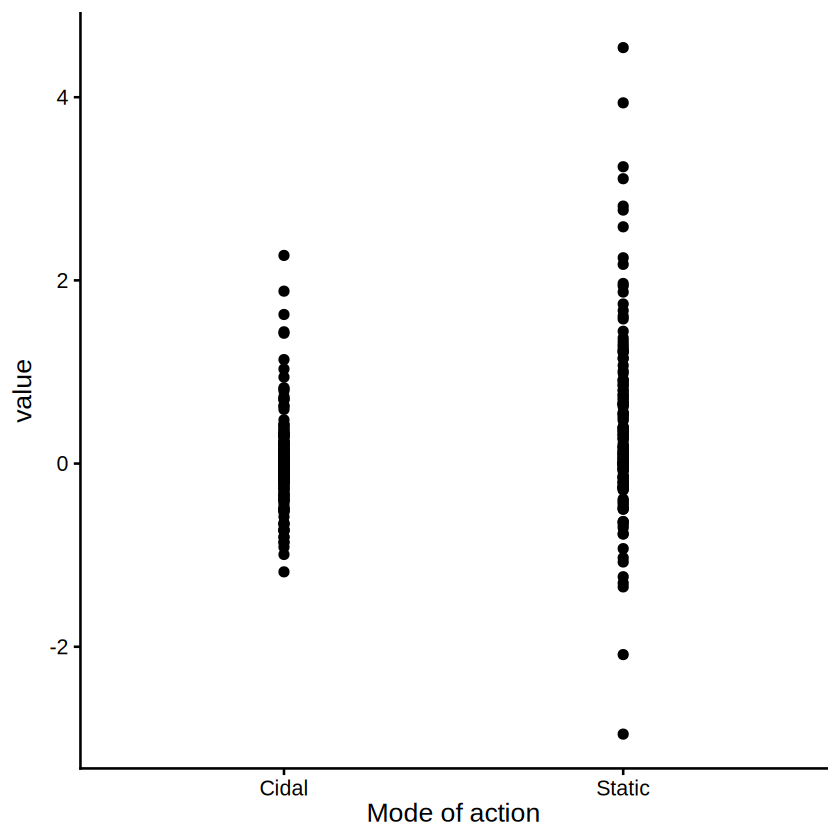

In [64]:
df_longer |>
  ggplot(aes(x=`Mode of action`, y=value)) +
  geom_point() +
  theme_classic(base_size = 16)

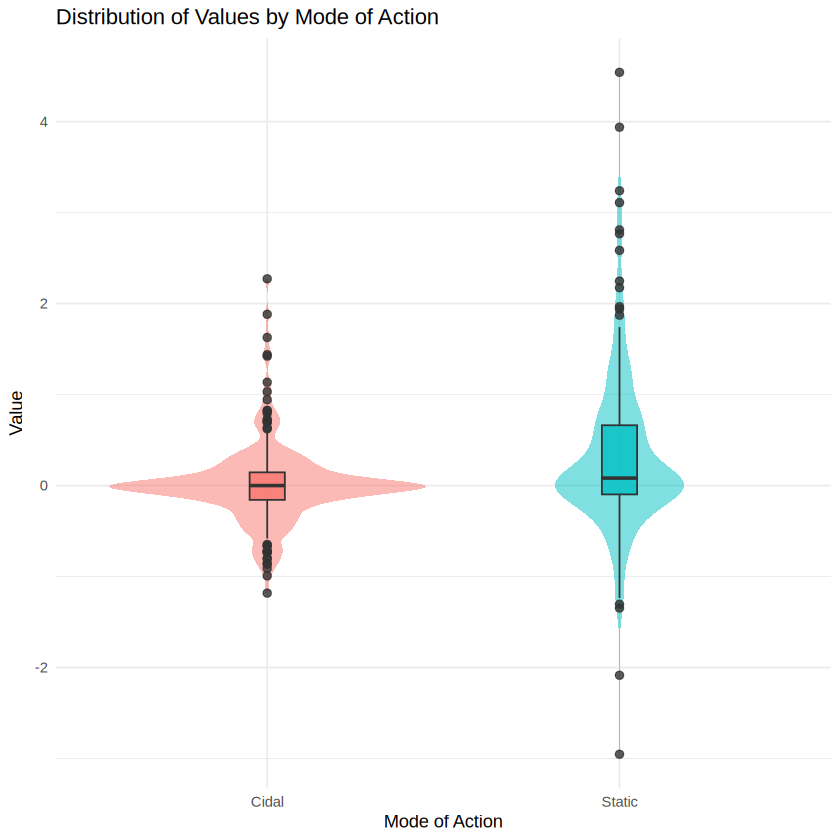

In [66]:
ggplot(df_longer, aes(x = `Mode of action`, y = value, fill = `Mode of action`)) +
  geom_violin(alpha = 0.5, color = NA) +
  geom_boxplot(width = 0.1, alpha = 0.8, outlier.size = 2) +
  theme_minimal() +
  labs(
    title = "Distribution of Values by Mode of Action",
    x = "Mode of Action",
    y = "Value"
  ) +
  theme(legend.position = "none")

Humor Sans already registered with pdfFont().

Liberation Mono already registered with pdfFont().

Liberation Sans already registered with pdfFont().

Liberation Serif already registered with pdfFont().

Humor Sans already registered with postscriptFont().

Liberation Mono already registered with postscriptFont().

Liberation Sans already registered with postscriptFont().

Liberation Serif already registered with postscriptFont().

Saving 6.67 x 6.67 in image


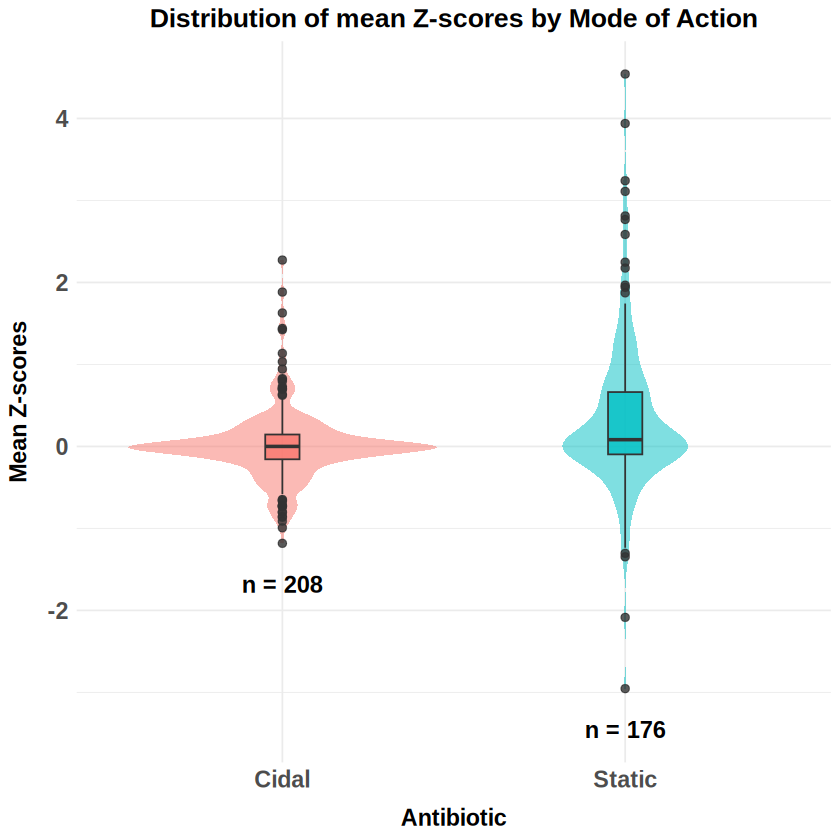

In [78]:
# To ensure consistent font rendering between Colab and saved files,
# it's best to register and use a common font family.
# First, import system fonts (run this once per session or if fonts change)
# font_import(paths = c("/usr/share/fonts/truetype/liberation"), prompt = FALSE) # Example for Liberation Sans
# fonts()
# loadfonts(device = "postscript") # For PDF output
# loadfonts(device = "win") # For Windows devices
loadfonts(device = "all") # Loads all fonts for all devices


# Define the function to calculate counts and position them
give_n <- function(x) {
  return(data.frame(y = min(x, na.rm = TRUE) - 0.5, label = paste0("n = ", length(na.omit(x)))))
}

ggplot(df_longer, aes(x = `Mode of action`, y = value, fill = `Mode of action`)) +
  geom_violin(alpha = 0.5, color = NA) +
  geom_boxplot(width = 0.1, alpha = 0.8, outlier.size = 2) +
  # Add counts at the bottom using stat_summary
  stat_summary(fun.data = give_n, geom = "text",
               position = position_dodge(0.9), size = 5, fontface = "bold") +
  theme_minimal() +
  labs(
    title = "Distribution of mean Z-scores by Mode of Action",
    x = "Antibiotic",
    y = "Mean Z-scores"
  ) +
  theme(
    legend.position = "none",
    # Specify a consistent font family for all text elements
    text = element_text(family = "Liberation Sans"), # Explicitly use 'Liberation Sans'
    # Increase size of the x-axis and y-axis labels (tick labels)
    axis.text.x = element_text(size = 14, face = "bold"),
    axis.text.y = element_text(size = 14, face = "bold"),
    # Increase size of the axis titles
    axis.title.x = element_text(size = 14, face = "bold", margin = margin(t = 10)),
    axis.title.y = element_text(size = 14, face = "bold", margin = margin(r = 10)),
    # Increase size of the plot title
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )
  ggsave("test1.png", dpi = 300)